# Consigna

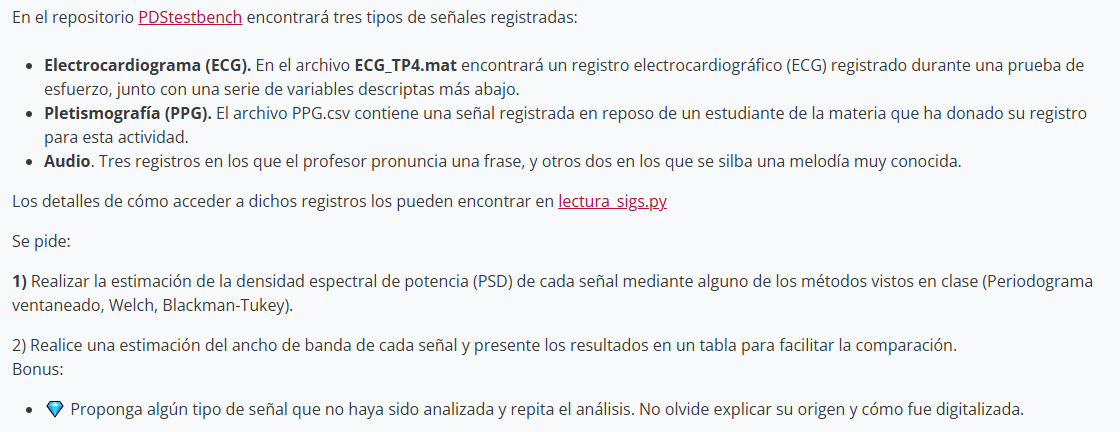

# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [97]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Generates Gaussian noise, with variance var and zero mean.

        Note: This distribution corresponds to "white noise". (Extracted from ASYS notes, Stochastic process - White Noise)
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=np.sqrt(var), size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    pot_signal = np.mean(xx**2)
    var_noise = pot_signal / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    '''power(x: np.ndarray) -> float:
        Returns the power of the signal x, defined as the mean of the square of the Voltage signal. 
    '''
    return np.mean(np.mean(x)**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))

def mi_adc(xx, Vfs, bits=4):
    '''mi_adc
    Quantizes the signal xx like an ADC with Vfs and bits.
    xx: Signal to be quantized.
    Vfs: ADC [0, Vfs]
    bits: Number of bits of the ADC.
    ''' 
    q = Vfs/(2**bits) 
    xq = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xq, vmin, vmax, out=xq)
    #xq[xq > vmax] = vmax
    #xq[xq < vmin] = vmin
    return xq

def autocorrelate(xx: np.ndarray) -> np.ndarray:
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr

def mod_db(xx: np.ndarray) -> np.ndarray:
    return 20*np.log10(np.abs(xx))

def mod_dbw(xx: np.ndarray) -> np.ndarray:
    return 10*np.log10(np.abs(xx))

def freq_axis(xx: np.ndarray, fs: float) -> np.ndarray:
    '''freq_axis
    
    Equal to np.fft.fftfreq. It generates the correct freq axis for the fft algorithm.
    Axis has the form:
    [0, △f, 2△f, ..., fs/2, -fs/2, -(fs/2-△f), ..., -△f]
    Note: the positive half always starts with 0. The negative half always starts with -fs/2, so, the negative half has one extra value if the length of the signal is even.
    xx: signal to generate the axis for. Only the length is used.
    fs: sampling frequency
    '''
    nn = xx.shape[0]
    half = np.arange(0, fs/2, fs/nn)
    ff = np.concatenate((half, -half[::-1] - fs/nn))
    ff = ff[:nn]
    return ff.reshape(-1,1)

# Respuesta

### Señales a procesar
* ECG: Electrocardiograma.
* PPG: 
* WAV: Archivo de audio con la cucaracha

In [98]:
import scipy.io as sio
from scipy import signal as sig
import matplotlib.pyplot as plt
%matplotlib qt

####### Señales 
fs_ecg = 1000 # Hz
ecg = np.load(r'E:\Agustin\Escritorio\Procesamiento-Digital-de-Se-ales---2026\TS6\ecg_sin_ruido.npy')

fs_ppg = 400 # Hz
ppg = np.load(r'E:\Agustin\Escritorio\Procesamiento-Digital-de-Se-ales---2026\TS6\ppg_sin_ruido.npy')

fs_audio, wav_data = sio.wavfile.read(r'E:\Agustin\Escritorio\Procesamiento-Digital-de-Se-ales---2026\TS6\la cucaracha.wav')



In [99]:
plt.figure()
plt.plot(ecg)
plt.xlabel("t [s]")
plt.title("ECG Sin Ruido")
plt.show()

plt.figure()
plt.plot(ppg)
plt.title("PPG Sin Ruido")
plt.xlabel("t [s]")
plt.show()

plt.figure()
plt.plot(wav_data)
plt.xlabel("t [s]")
plt.title("WAV (La cucaracha)")
plt.show()


### Welch

Comenzaremos probando el algoritmo de Welch con 3 señales sin ruido.

In [100]:
f_ecg, Pxx_ecg = sig.welch(ecg, fs=fs_ecg)

plt.figure()
plt.plot(f_ecg, 20*np.log(np.abs(Pxx_ecg)))
plt.title("Pxx de PPG")
plt.xlabel("f [Hz]")
plt.ylabel("A [dB]")

plt.show()  

In [101]:
f_ppg, Pxx_ppg = sig.welch(ppg, fs=fs_ppg)

plt.figure("PPG")
plt.plot(f_ppg, 20*np.log(np.abs(Pxx_ppg)))
plt.title("Pxx de PPG")
plt.xlabel("f [Hz]")
plt.ylabel("A [dB]")
plt.show()  

In [102]:
f_wav, Pxx_wav = sig.welch(wav_data, fs=fs_audio)

plt.figure()
plt.plot(f_wav, 20*np.log(np.abs(Pxx_wav)))
plt.title("Pxx de \"La cucaracha\"")
plt.xlabel("f [Hz]")
plt.ylabel("A [dB]")
plt.show()  

Ahora realizaremos el mismo algoritmo con el doble de muestras (zero padding) y probaremos el resultado con distintos valores de K, siendo K la cantidad de segmentos de welch.


In [103]:
K = [2, 5, 10, 15, 20]

In [111]:
N = len(wav_data)
print(f"N de wav: {N}")

plt.figure("Pxx Wav")
for k in K:
    f_wav, Pxx_wav = sig.welch(wav_data, fs=fs_audio, nperseg=N/k, nfft= 2*N)
    plt.plot(f_wav, 20*np.log(np.abs(Pxx_wav)), label=f"K={k}")
plt.legend()
plt.xlim(0, 4000)
plt.xlabel("f [Hz]")
plt.ylabel("A [dB]")

plt.show()


N de wav: 144000


In [114]:
N = len(ecg)
print(f"N de ecg: {N}")

plt.figure("Pxx ECG")
for k in K:
    f_ecg, Pxx_ecg = sig.welch(ecg, fs=fs_ecg, nperseg=N/k, nfft= 2*N)
    plt.plot(f_ecg, 20*np.log(np.abs(Pxx_ecg)), label=f"K={k}")
plt.legend()
plt.xlim(0, 300)
plt.xlabel("f [Hz]")
plt.ylabel("A [dB]")

plt.show()


N de ecg: 30000


In [115]:
N = len(ppg)
print(f"N de ppg: {N}")

plt.figure("Pxx PPG")
for k in K: 
    f_ppg, Pxx_ppg = sig.welch(ppg, fs=fs_ppg, nperseg=N/k, nfft= 2*N)
    plt.plot(f_ppg, 20*np.log(np.abs(Pxx_ppg)), label=f"K={k}")
plt.legend()
plt.xlim(0, 40)
plt.xlabel("f [Hz]")
plt.ylabel("A [dB]")
plt.show()


N de ppg: 44919


Se puede observar que un K menor genera mayores oscilaciones. El K mayor logra suavizar la curva debido a la mayor cantidad de promedios. 
El suavizado, para grandes K puede alejarse de los valores. Se debe estimar un valor de K óptimo mediante intuición.

En este caso se consideró al K=15 como el mejor, pero podría elegirse otro.

### Peridograma ventaneado

El algoritmo de periodograma corresponde al mismo que una FFT tradicional.
Se realizarán las mismas pruebas que antes con el algoritmo FFT

In [107]:
from scipy.signal import windows
N = len(ecg)
window = windows.blackman(N)
Pxx_ecg = np.fft.fft((ecg**2)*window, n=2*N)/N

In [108]:
from scipy.signal import windows
N = len(ppg)
window = windows.blackman(N)
Pxx_ppg = np.fft.fft((ppg**2)*window, n=2*N)/N

In [109]:
from scipy.signal import windows
N = len(wav_data)
window = windows.blackman(N)
Pxx_wav = np.fft.fft((wav_data**2)*window, n=2*N)/N

### Blackman Tuck

Se debe definir el algoritmo, puesto que scipy no lo tiene

In [ ]:
def blackman_tukey(x,  M = None):    
    
    # N = len(x)
    x_z = x.shape
    N = np.max(x_z)
    
    if M is None:
        M = N//5
    
    r_len = 2*M-1

    # hay que aplanar los arrays por np.correlate.
    # usaremos el modo same que simplifica el tratamiento
    # de la autocorr
    xx = x.ravel()[:r_len];

    r = np.correlate(xx, xx, mode='same') / r_len

    Px = np.abs(np.fft.fft(r * sig.windows.blackman(r_len), n = N) )

    Px = Px.reshape(x_z)

    return Px;
    ## SACAR EL VALOR MEDIO ANTES DE CORRELACIONAR!!!

def my_blackman_tukey(x, M):
    pass


### Estimación de Ancho de Banda

Se va a realizar una primera estimación del ancho de banda. Es importante destacar que estas señales no poseen ruido, por lo que puede dar peores resultados con ruido añadido.

Otra consideración es que estamos utilizando métodos no paramétricos. Eso quiere decir que "no conocemos" nada de la señal y el método es genérico para cualquier señal. 
Un método paramétrico supone cosas de la señal y permite modelos más precisos y ligeros aplicados para determinados problemas.

Se aclara esto último porque los ecg, ppg y la voz humana (el wav con música) todos presentan caractéristicas particulares que podrían parametrizarse.

Se estimará el ancho de banda d euna señal pasabajos.
Se calculará como la integral de la señal Pxx. Se obtendrá el índice donde la Pxx no sea mayor que el margen que se busque

In [186]:
def est_bw(x, lim = .95):
    max_pot = np.sum(x)
    cum_pot = 0
    idx_bw = 0
    for i in range(len(x)):
        cum_pot += x[i]
        if cum_pot >= max_pot * lim:
            idx_bw = i
            break;
    return idx_bw

def est_bw_2(x, lim = .95):
    pot_acum = np.cumsum(x)
    pot_acum = pot_acum / pot_acum[-1]
    idx = np.argwhere(pot_acum >= lim)
    idx = idx.flatten()[0]
    return idx

def est_bw_bp(x, lim = .95):
    pot_acum = np.cumsum(x)
    pot_acum = pot_acum / pot_acum[-1]
    idx_1 = np.argwhere(pot_acum >= ((1-lim)/2))
    idx_1 = idx_1.flatten()[0]
    
    idx_2 = np.argwhere(pot_acum >= ((1-lim)/2 + lim))
    idx_2 = idx_2.flatten()[0]

    return idx_1,  idx_2


In [ ]:
K = 15
f_ecg, Pxx_ecg = sig.welch(ecg, fs=fs_ecg, nperseg=len(ecg)/K)
bw_ecg = f_ecg[est_bw_2(Pxx_ecg)]
print(f"Ancho de banda del ECG: {bw_ecg:.3g} Hz")

plt.figure(f"Pxx ECG con K={K}")
plt.subplot(2,1,1)
plt.plot(f_ecg, 10*np.log10(Pxx_ecg))
plt.title(f"Pxx ECG con K={K}")
plt.xlabel("f [Hz]")
plt.ylabel("P [dB]")
plt.axvline(bw_ecg, color="r", linestyle='--', label='BW')

plt.subplot(2,1,2)
acumulado_normalizado = np.cumsum(Pxx_ecg)
acumulado_normalizado = acumulado_normalizado / acumulado_normalizado[-1]
plt.plot(f_ecg, acumulado_normalizado)
plt.title("Densidad Acumulada de Potencia ECG")
plt.xlabel("f [Hz]")
plt.ylabel("P [dB]")
plt.axvline(bw_ecg, color="r", linestyle='--', label='BW')

plt.tight_layout()
plt.legend()
plt.show()

Ancho de banda del ECG: 22.5 Hz


In [188]:
K = 15
f_ppg, Pxx_ppg = sig.welch(ppg, fs=fs_ppg, nperseg=len(ppg)/K)
bw_ppg = f_ppg[est_bw_2(Pxx_ppg)]
print(f"Ancho de banda del PPG: {bw_ppg:.3g} Hz")

plt.figure(f"Pxx PPG con K={K}")
plt.subplot(2,1,1)
plt.plot(f_ppg, 10*np.log10(Pxx_ppg))
plt.title(f"Pxx PPG con K={K}")
plt.xlabel("f [Hz]")
plt.ylabel("P [dB]")
plt.axvline(bw_ppg, color="r", linestyle='--', label='BW')
plt.legend()

acumulado_normalizado = np.cumsum(Pxx_ppg)
acumulado_normalizado = acumulado_normalizado / acumulado_normalizado[-1]
plt.subplot(2,1,2)
plt.plot(f_ppg, acumulado_normalizado)
plt.title("Densidad Acumulada de Potencia PPG")
plt.xlabel("f [Hz]")
plt.ylabel("P [dB]")
plt.axvline(bw_ppg, color="r", linestyle='--', label='BW')

plt.tight_layout()
plt.legend()
plt.show()

Ancho de banda del PPG: 4.01 Hz


In [189]:
K = 15
lim = .95

f_wav, Pxx_wav = sig.welch(wav_data, fs=fs_audio, nperseg=len(wav_data)/K)
idx1, idx2 = est_bw_bp(Pxx_wav, lim)
bw_wav = f_wav[idx2] - f_wav[idx1]
print(f"Ancho de banda del Wav: {bw_wav:.3g} Hz")
print(f"Frecuencia de corte Inferior: {f_wav[idx1]:.3g} Hz")
print(f"Frecuencia de corte Superior: {f_wav[idx2]:.3g} Hz")

plt.figure(f"Pxx WAV con K={K}")
plt.subplot(2,1,1)
plt.plot(f_wav, 10*np.log10(Pxx_wav))
plt.title(f"Pxx WAV con K={K} y limite de potencia = {lim}")
plt.xlabel("f [Hz]")
plt.ylabel("P [dB]")
plt.axvline(f_wav[idx2], color="r", linestyle='--', label='BW')
plt.axvline(f_wav[idx1], color="r", linestyle='--')
plt.legend()
plt.show()

acumulado_normalizado = np.cumsum(Pxx_wav)
acumulado_normalizado = acumulado_normalizado / acumulado_normalizado[-1]
plt.subplot(2,1,2)
plt.plot(f_wav, acumulado_normalizado)
plt.title("Densidad Acumulada de Potencia WAV")
plt.xlabel("f [Hz]")
plt.ylabel("P [dB]")
plt.axvline(f_wav[idx2], color="r", linestyle='--', label='BW')
plt.axvline(f_wav[idx1], color="r", linestyle='--')

plt.tight_layout()
plt.legend()
plt.show()

Ancho de banda del Wav: 960 Hz
Frecuencia de corte Inferior: 1.01e+03 Hz
Frecuencia de corte Superior: 1.97e+03 Hz
